

# Підготовка даних до аналізу






<h2>Мета</h2>

Ознайомитись з методикою первинної обробки даних. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати структуру завантажених даних
* Виправляти формати даних
* Знаходити та заповнювати пропуски в даних
* Знаходити викиди та некоректні значення
* Будувати прості візуалізації




<a name="task"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>





1. Скачати дані із файлу, записати у dataframe. Дослідити структуру даних.
2. Виправити помилки в даних.
3. Побудувати діаграми розмаху та гістограми.
4. Заповнити пропуски.
5. Додати стовпчик із щільністю населення.



<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити структуру даних</p>
</div>


Зчитую дані з файлу у датафрейм


In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('Data2.csv', sep=';', encoding='cp1252')

<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
DATA_PATH = 'data/Data2.csv'

# Зчитуємо файл із заданим розділяючим символом ";"
df = pd.read_csv(DATA_PATH, sep=';')

'''
Зауваження: попередній код зчитування з файлу підходить для
файлів з кодуванням utf-8. Проте файл Data2.csv спочатку мав інше
кодування. Дане кодування потрібно вказати в якості параметру:
    
'''

df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')


```
</details>




Досліджую структуру даних


In [2]:
display(df.head())

print("--- Загальна інформація про датафрейм ---")
df.info()

display(df.describe(include='all'))

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
0,Afghanistan,South Asia,"561,7787463",34656032.0,"9809,225",652860
1,Albania,Europe & Central Asia,"4124,98239",2876101.0,"5716,853",28750
2,Algeria,Middle East & North Africa,"3916,881571",40606052.0,"145400,217",2381740
3,American Samoa,East Asia & Pacific,"11834,74523",55599.0,NaN,200
4,Andorra,Europe & Central Asia,"36988,62203",77281.0,"462,042",470


--- Загальна інформація про датафрейм ---
<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    217 non-null    str    
 1   Region          217 non-null    str    
 2   GDP per capita  190 non-null    str    
 3   Populatiion     216 non-null    float64
 4   CO2 emission    205 non-null    str    
 5   Area            216 non-null    str    
dtypes: float64(1), str(5)
memory usage: 10.3 KB


,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
count,217,217,190,2.160000e+02,205,216
unique,217,7,190,NaN,202,212
top,Afghanistan,Europe & Central Asia,"561,7787463",NaN,"495,045",460
freq,1,58,1,NaN,2,3
mean,NaN,NaN,NaN,4.338952e+07,NaN,NaN
std,NaN,NaN,NaN,1.879574e+08,NaN,NaN
min,NaN,NaN,NaN,1.109700e+04,NaN,NaN
25%,NaN,NaN,NaN,7.900265e+05,NaN,NaN
50%,NaN,NaN,NaN,6.318988e+06,NaN,NaN
75%,NaN,NaN,NaN,2.380373e+07,NaN,NaN


Бачу наступні проблеми в даних:
1. Одруківка в назві - Populatiion замість Population
2. GPD per capita, CO2 emission та Area мають неправильний тип даних - рядок замість числа
3. Підозрілі значення - наприклад, найбільший Population приблизно 2 млрд., що значно перевищує реальні дані.
4. Є пропущені значення в GDP per capita, Population, CO2 emission та Area


<a name="task2"></a> <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2"> Завдання  #2: </h2>

<p>Виправити помилки в даних</p>
</div>


<b>Проблема 1. Неправильні назви</b>
<p>
    Для виправлення зроблю наступне: заміню Populatiion на Population за допомогою метода rename
</p>
<p>   Перевіряю результат.</p>

In [3]:
print("Поточні назви стовпців:")
print(df.columns.tolist())

df.rename(columns={'Populatiion': 'Population'}, inplace=True)

print("Виправлені назви стовпців:")
print(df.columns.tolist())

Поточні назви стовпців:
['Country Name', 'Region', 'GDP per capita', 'Populatiion', 'CO2 emission', 'Area']
Виправлені назви стовпців:
['Country Name', 'Region', 'GDP per capita', 'Population', 'CO2 emission', 'Area']


<b>Проблема 2. Неправильні типи даних</b>
<p>
    Відкрию файл даних поряд у вікні текстового редактора і постараюсь розібратись, чому типи даних визначились неправильно. </p>
<p>Для виправлення зроблю наступне: заміню коми на крапки та приберу пробіли; зміню тип даних на float


</p>
<p>   Перевіряю результат.</p>

In [4]:
numeric_columns = ['GDP per capita', 'CO2 emission', 'Area']

for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.').str.replace(' ', '')
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Типи даних після виправлення:")
display(df.info())

Типи даних після виправлення:
<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    217 non-null    str    
 1   Region          217 non-null    str    
 2   GDP per capita  190 non-null    float64
 3   Population      216 non-null    float64
 4   CO2 emission    205 non-null    float64
 5   Area            216 non-null    float64
dtypes: float64(4), str(2)
memory usage: 10.3 KB


None

<b>Проблема 3. Неправильні значення (занадто великі або занадто малі)</b>
<p>
    Для виправлення зроблю наступне: візьму значення GPD та Area по модулю, приберу три зайві нулі з популяції Латвії
</p>
<p>   Перевіряю результат.
</p>

In [5]:
import numpy as np

print("Статистика перед виправленням:")
print(df[['GDP per capita', 'Population', 'CO2 emission', 'Area']].describe())
display(df[df['Country Name'] == 'Latvia'])

df.loc[df['Area'] == 0, 'Area'] = np.nan

df['GDP per capita'] = df['GDP per capita'].abs()
df['Area'] = df['Area'].abs()

df.loc[df['Country Name'] == 'Latvia', 'Population'] /= 1000

print("Статистика після виправлення:")
print(df[['GDP per capita', 'Population', 'CO2 emission', 'Area']].describe())
display(df[df['Country Name'] == 'Latvia'])

Статистика перед виправленням:
       GDP per capita    Population  CO2 emission          Area
count      190.000000  2.160000e+02  2.050000e+02  2.160000e+02
mean     13374.833168  4.338952e+07  1.651141e+05  6.149355e+05
std      18091.785849  1.879574e+08  8.335357e+05  1.833868e+06
min      -6722.223536  1.109700e+04  1.100100e+01 -6.765900e+05
25%       1926.540477  7.900265e+05  1.334788e+03  1.015000e+04
50%       5226.289415  6.318988e+06  9.108828e+03  9.077250e+04
75%      16003.299818  2.380373e+07  5.986378e+04  4.474050e+05
max     100738.684200  1.960424e+09  1.029193e+07  1.709825e+07


,Country Name,Region,GDP per capita,Population,CO2 emission,Area
108,Latvia,Europe & Central Asia,14071.02723,1.960424e+09,6974.634,64490.0


Статистика після виправлення:
       GDP per capita    Population  CO2 emission          Area
count      190.000000  2.160000e+02  2.050000e+02  2.150000e+02
mean     13445.593416  3.432256e+07  1.651141e+05  6.240895e+05
std      18038.981506  1.347600e+08  8.335357e+05  1.835527e+06
min        285.727442  1.109700e+04  1.100100e+01  2.000000e+00
25%       2031.779671  7.900265e+05  1.334788e+03  1.093850e+04
50%       5235.308547  6.221590e+06  9.108828e+03  9.303000e+04
75%      16003.299818  2.350337e+07  5.986378e+04  4.551300e+05
max     100738.684200  1.378665e+09  1.029193e+07  1.709825e+07


,Country Name,Region,GDP per capita,Population,CO2 emission,Area
108,Latvia,Europe & Central Asia,14071.02723,1960424.0,6974.634,64490.0


<a name="task3"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5"> Завдання  #3: </h2>

<p>Побудувати діаграми розмаху та гістограми</p>
</div>


Для побудови графіків скористайтесь бібліотекою Matplotlib. Спробуйте погратись з кольорами, розмірами та підписами.


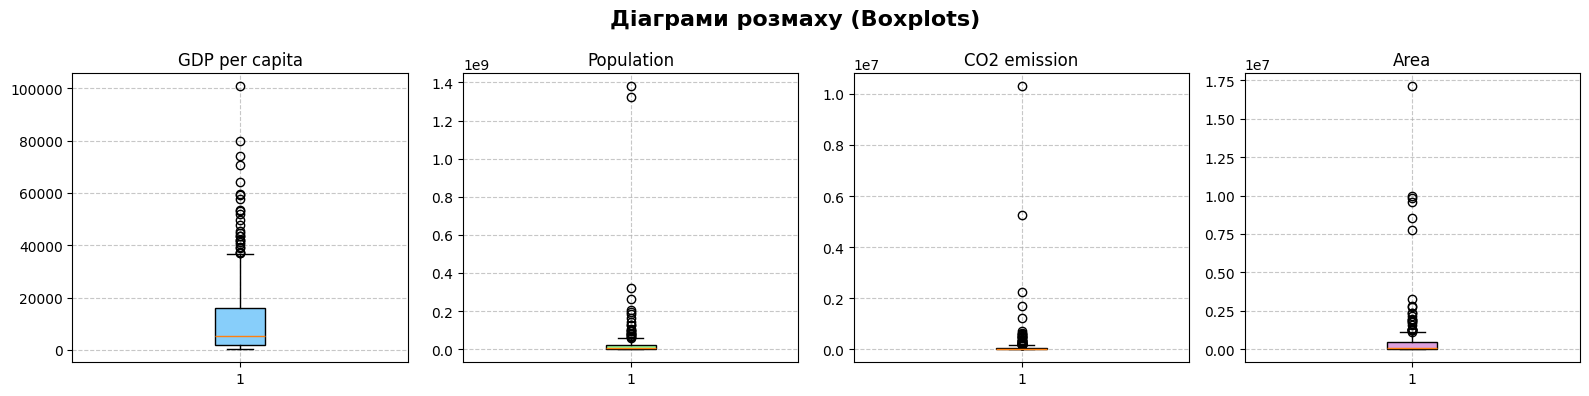

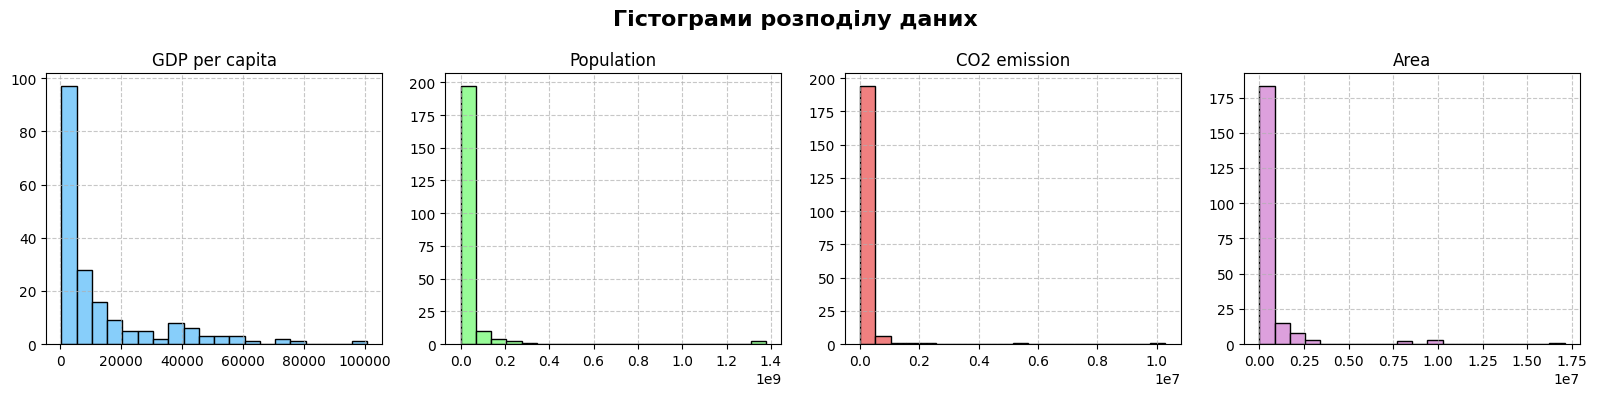

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Діаграми розмаху (Boxplots)', fontsize=16, fontweight='bold')

# оскільки matplotlib не підтримує nan, потрібно видалити їх перед побудовою
axs[0].boxplot(df['GDP per capita'].dropna(), patch_artist=True, boxprops=dict(facecolor='#87CEFA'))
axs[0].set_title('GDP per capita')

axs[1].boxplot(df['Population'].dropna(), patch_artist=True, boxprops=dict(facecolor='#98FB98'))
axs[1].set_title('Population')

axs[2].boxplot(df['CO2 emission'].dropna(), patch_artist=True, boxprops=dict(facecolor='#F08080'))
axs[2].set_title('CO2 emission')

axs[3].boxplot(df['Area'].dropna(), patch_artist=True, boxprops=dict(facecolor='#DDA0DD'))
axs[3].set_title('Area')

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # автовідступи
plt.show()

# --------------------------

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Гістограми розподілу даних', fontsize=16, fontweight='bold')

axs[0].hist(df['GDP per capita'].dropna(), bins=20, color='#87CEFA', edgecolor='black')
axs[0].set_title('GDP per capita')

axs[1].hist(df['Population'].dropna(), bins=20, color='#98FB98', edgecolor='black')
axs[1].set_title('Population')

axs[2].hist(df['CO2 emission'].dropna(), bins=20, color='#F08080', edgecolor='black')
axs[2].set_title('CO2 emission')

axs[3].hist(df['Area'].dropna(), bins=20, color='#DDA0DD', edgecolor='black')
axs[3].set_title('Area')

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
# Імпортуємо бібліотеку Matplotlib
import matplotlib.pyplot as plt
    
# діаграми розмаху для "GDP per capita", "Population", "CO2 emission" та "Area"

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle('Діаграми розмаху', fontsize=16)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['GDP per capita'])

axs[1].set_title('Population')
axs[1].boxplot(df['Population'])

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['CO2 emission'])

axs[3].set_title('Area')
axs[3].boxplot(df['Area'])

plt.show()

```
</details>




<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3"> Завдання  #4: </h2>
<b>Проблема 4. Пропущені значення </b>
<p>Як найкраще заповнити пропуски підкажуть візуалізації з попереднього завдання.</p>
</div>


Заповнювати пропуски для ознак GPD per capita, Population, CO2 emission та Area буду медіаною, оскільки діаграми демонструють сильну асиметрію - в таких випадках середнє арифметичне буде сильно спотворене, а медіана є стійкою до аномалій. Згрупую по регіонах щоб зробити заповнення максимально точним.

In [7]:
print(f"Пропущені значення перед заповненням:")
print(df.isnull().sum())
cols_to_fill = ['GDP per capita', 'Population', 'CO2 emission', 'Area']

for col in cols_to_fill:
    df[col] = df[col].fillna(df.groupby('Region')[col].transform('median'))

Пропущені значення перед заповненням:
Country Name       0
Region             0
GDP per capita    27
Population         1
CO2 emission      12
Area               2
dtype: int64


Досліджую структуру даних, чи всі пропуски заповнено


In [8]:
print("Інформація про датафрейм після заповнення пропусків:")
print(df.info())

print("Пропущені значення:")
print(df.isnull().sum())

print("Статистичні показники:")
print(df.describe())

Інформація про датафрейм після заповнення пропусків:
<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    217 non-null    str    
 1   Region          217 non-null    str    
 2   GDP per capita  217 non-null    float64
 3   Population      217 non-null    float64
 4   CO2 emission    217 non-null    float64
 5   Area            217 non-null    float64
dtypes: float64(4), str(2)
memory usage: 10.3 KB
None
Пропущені значення:
Country Name      0
Region            0
GDP per capita    0
Population        0
CO2 emission      0
Area              0
dtype: int64
Статистичні показники:
       GDP per capita    Population  CO2 emission          Area
count      217.000000  2.170000e+02  2.170000e+02  2.170000e+02
mean     12997.297937  3.422152e+07  1.572972e+05  6.641028e+05
std      17212.901697  1.344559e+08  8.107100e+05  1.933150e+06
min     

 <a name="task5"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4"> Завдання  #5: </h2>

<p>Додати стовпчик із щільністю населення</p>
</div>


Щільність населення розрахую по формулі такій-то і додам у стовпчик такий-то.


In [9]:
df['Density'] = df['Population'] / df['Area']

display(df[['Country Name', 'Population', 'Area', 'Density']].head())

,Country Name,Population,Area,Density
0,Afghanistan,34656032.0,652860.0,53.083405
1,Albania,2876101.0,28750.0,100.038296
2,Algeria,40606052.0,2381740.0,17.048902
3,American Samoa,55599.0,200.0,277.995000
4,Andorra,77281.0,470.0,164.427660


<a name="task6"></a>
 <div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>



1. Яка країна має найменшу площу?
2. Знайдіть країну з найбільшою щільністю населення у світі? У Європі та центральній Азії?
3. Яка країна має найбільший ВВП на людину (GDP per capita)?
4. Покажіть топ 5 країн та 5 останніх країн по ВВП на людину.



<details><summary>Натисніть тут, щоб побачити підказку</summary>
    
Скористайтесь методами <code>loc()</code> для повернення зрізу датафрейму, <code>idxmax()</code> для повернення номера рядка з найбільшим значенням якогось показника у стовпці та <code>idxmin()</code> для повернення номера рядка з найменшим значенням якогось показника у стовпці
    
```python
df.loc[df['GDP per capita'].idxmax()]

```
    
Гарно оформити виведення інформації допоможе <code>print()</code>  
```python
print('\n' + df.loc[df['GDP per capita'].idxmax(), 'Country Name'] + ' має найбільший ВВП на людину')
```   
  
</details>


In [10]:
# 1. Яка країна має найменшу площу?
smallest_area = df.loc[df['Area'].idxmin(), 'Country Name']
print(f"1. Найменшу площу має: {smallest_area}")

# --------------------------

max_density_world = df.loc[df['Density'].idxmax(), 'Country Name']
print(f"2. Найбільша щільність населення у світі: {max_density_world}")

# Фільтруємо датафрейм тільки для Європи та Центральної Азії
eu_asia_df = df[df['Region'] == 'Europe & Central Asia']
max_density_eu = eu_asia_df.loc[eu_asia_df['Density'].idxmax(), 'Country Name']
print(f"   Найбільша щільність у Європі та Центральній Азії: {max_density_eu}")

# --------------------------

max_gdp = df.loc[df['GDP per capita'].idxmax(), 'Country Name']
print(f"3. Найбільший ВВП на людину має: {max_gdp}")

# --------------------------

print("4. Топ-5 найбагатших країн за ВВП на людину:")
display(df.nlargest(5, 'GDP per capita')[['Country Name', 'GDP per capita']])

print("  Топ-5 країн з найменшим ВВП на людину (найбідніші):")
display(df.nsmallest(5, 'GDP per capita')[['Country Name', 'GDP per capita']])

1. Найменшу площу має: Monaco
2. Найбільша щільність населення у світі: Macao SAR, China
   Найбільша щільність у Європі та Центральній Азії: Monaco
3. Найбільший ВВП на людину має: Luxembourg
4. Топ-5 найбагатших країн за ВВП на людину:


,Country Name,GDP per capita
115,Luxembourg,100738.68420
188,Switzerland,79887.51824
116,"Macao SAR, China",74017.18471
146,Norway,70868.12250
92,Ireland,64175.43824


  Топ-5 країн з найменшим ВВП на людину (найбідніші):


,Country Name,GDP per capita
31,Burundi,285.727442
119,Malawi,300.307665
134,Mozambique,382.069330
37,Central African Republic,382.213174
118,Madagascar,401.742270


Збережіть дані у новий файл 'clean_data.csv':


In [11]:
df.to_csv('clean_data.csv', index=False, encoding='utf-8')
print("Дані збережено у файл 'clean_data.csv'")

Дані збережено у файл 'clean_data.csv'


<h2>Виконав студент групи ІП-45  <br>Янов Богдан</h2>
